# Chapter 10.1 — Classification with Decision Trees

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Chapter 9 introduced supervised learning and its two branches. Chapter 10 works through one model of each kind, in three parts. This first part predicts a **category** with a decision tree: fourteen days of weather and whether golf was played, a tree grown from them by counting, and the tree read as rules. The same method is then applied to a real dataset — 150 iris flowers — with the scikit-learn library, and the homework asks questions of that dataset.

**In this chapter:** Supervised learning · Binary and multi-class · Decision trees · Choosing a question by counting · Growing the tree · IF–THEN rules · The iris flowers · scikit-learn · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Recognize a classification problem** — say when the answer is a category rather than a number, and whether the problem has two classes or several.
> - **Grow a tree** — explain how the algorithm chooses each question from labeled data, in plain counts, and when it stops.
> - **Read the tree** — turn every path from the root to a leaf into an IF–THEN rule.
> - **Predict a new case** — walk a new record from the root to a leaf, by hand and with a library, and say why a perfect score on the training data proves nothing yet.



**Contents**

- **10.1.1 · Supervised learning, and two kinds of answer** — the workflow; classification against regression
- **10.1.2 · The decision tree** — the model and its terms
- **10.1.3 · The fourteen golf days** — the training data
- **10.1.4 · Choosing the first question** — settled by majority, and pure groups
- **10.1.5 · Growing the whole tree** — the same search inside each mixed branch
- **10.1.6 · Reading the tree** — IF–THEN rules, and a new day
- **10.1.7 · The same tree, with scikit-learn** — three lines, and where the two trees differ
- **10.1.8 · A real dataset — the iris flowers** — the same method with scikit-learn
- **10.1.9 · Glossary** — the terms of this part
- **10.1.10 · Homework** — the graded work, on the iris flowers



> **How to use this notebook.** Each idea is explained first, then built in code one step per cell: the text above a code cell says what the step does and why it comes next, and its **Interpretation** says what the output will show. Run the cells in order — later cells use variables made by earlier ones. The **Try it** boxes are small ungraded challenges. The graded work is Section 10.1.10.

> **Continuing from Chapter 9.** Chapter 9 taught supervised learning, the train/test split and accuracy in full (Sections 9.3.2 and 9.3.6). They are only recapped here, in one place each, before they are used on this part's own model.



#### Setting up

One cell of preparation: numpy for arrays of numbers, pandas for tables, matplotlib for charts. Section 10.1.7 adds scikit-learn, the library that grows trees on real data, when it is needed.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
print("numpy", np.__version__, "· pandas", pd.__version__, "· ready")

numpy 2.4.6 · pandas 3.0.5 · ready


## 10.1.1 · Supervised learning, and two kinds of answer

*the workflow every model in Chapter 10 follows*

**Supervised learning** is learning from data that already carries the answers. Every record says what really happened — the customer bought or did not, the loan was approved or declined, golf was played or not — and the model learns the pattern that links the other columns to that answer. The columns used to predict are the **features**; the column to be predicted is the **target**. Chapter 9 introduced this idea; Chapter 10 builds two models with it.

> **The workflow.** Supervised learning follows six steps, whatever the model. (1) Start from labeled data. (2) Name the features and the target. (3) Split the rows into a training set the model learns from and a test set it never sees while learning. (4) Train: the algorithm finds the pattern in the training set. (5) Predict: the model is shown the test set's features only. (6) Evaluate: predicted is compared with actual.



#### The six steps

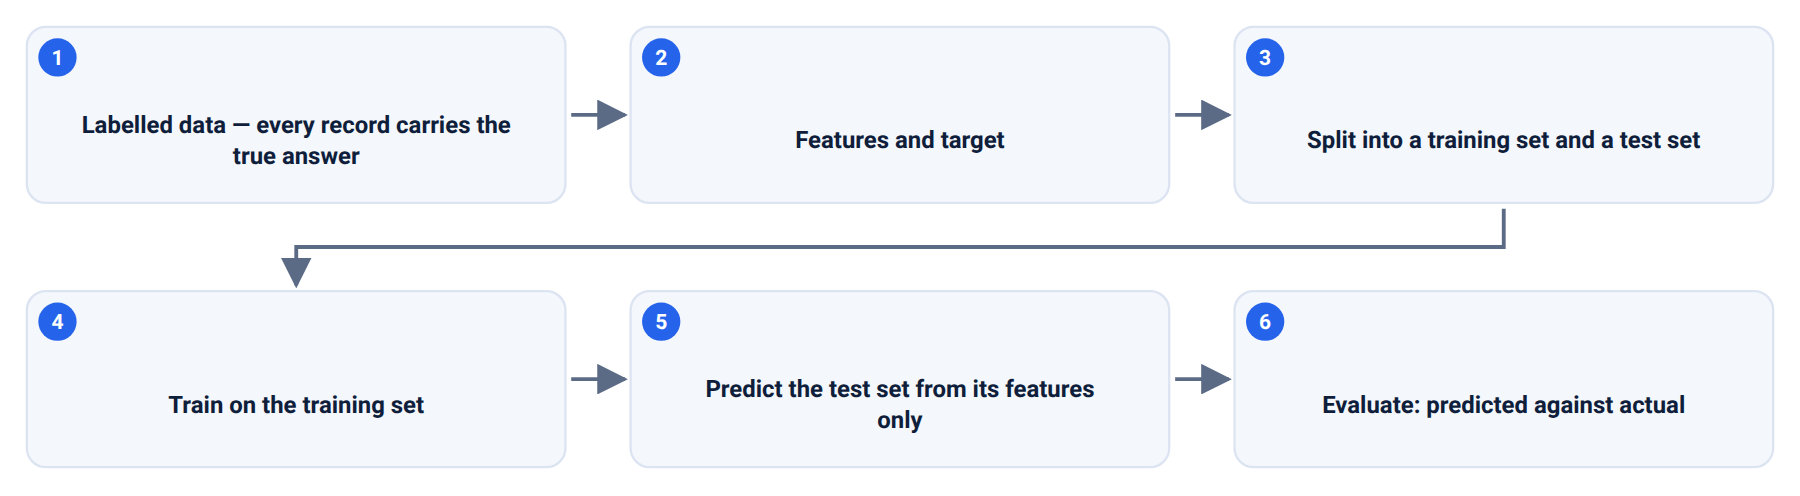

*The workflow of supervised learning. Part 10.1 carries out steps 1 to 4 and the prediction of step 5; Part 10.2 is step 6.*

> **The point that matters most.** The test set does have the real answers — they are simply hidden from the model while it predicts. Only afterwards are they uncovered and compared. That is what makes the score honest: the model could not have memorized them.



#### Two kinds of answer

What the target is decides the kind of task. When the target is a **category** — play or not, approve or decline — the task is **classification**, the subject of Parts 10.1 and 10.2. When it is a **number** — a price, a sales figure — the task is **regression**, the subject of Part 10.3. The workflow is the same; only the type of answer differs.

| Kind of classification | Number of classes | Examples |
|---|---|---|
| **Binary** | two | spam / not spam · churn / stay · approved / not approved · play / do not play |
| **Multi-class** | three or more | low / medium / high risk · bronze / silver / gold customer · which of five products a shopper buys next |

In a binary problem one of the two classes is named the **positive class** — the one being looked for, such as the churners or the days golf was played — and the evaluation in Part 10.2 is built around it. The **decision tree** handles both kinds without changing shape, and it is the one algorithm this chapter works through, because a person can read its answer, follow the path that produced it, and explain it to whoever must act on it.



## 10.1.2 · The decision tree

*the model and its terms*

> **Definition.** A **decision tree** is a hierarchical, tree-shaped model used for both classification and regression. One attribute is tested at each node, and every path from the **root node** ends in a **leaf node** that holds a prediction. To classify a new record, start at the root and follow the branch matching each test until a leaf is reached.

| Term | Meaning |
|---|---|
| **Root node** | The first attribute used to divide the data |
| **Branch / sub-tree** | A part of the whole tree |
| **Splitting** | Dividing a node into two or more sub-nodes |
| **Decision node** | An internal node that is split further |
| **Leaf node** | The end of a branch — a final prediction |
| **Pruning** | Removing a sub-node from the tree |



#### The anatomy of a tree

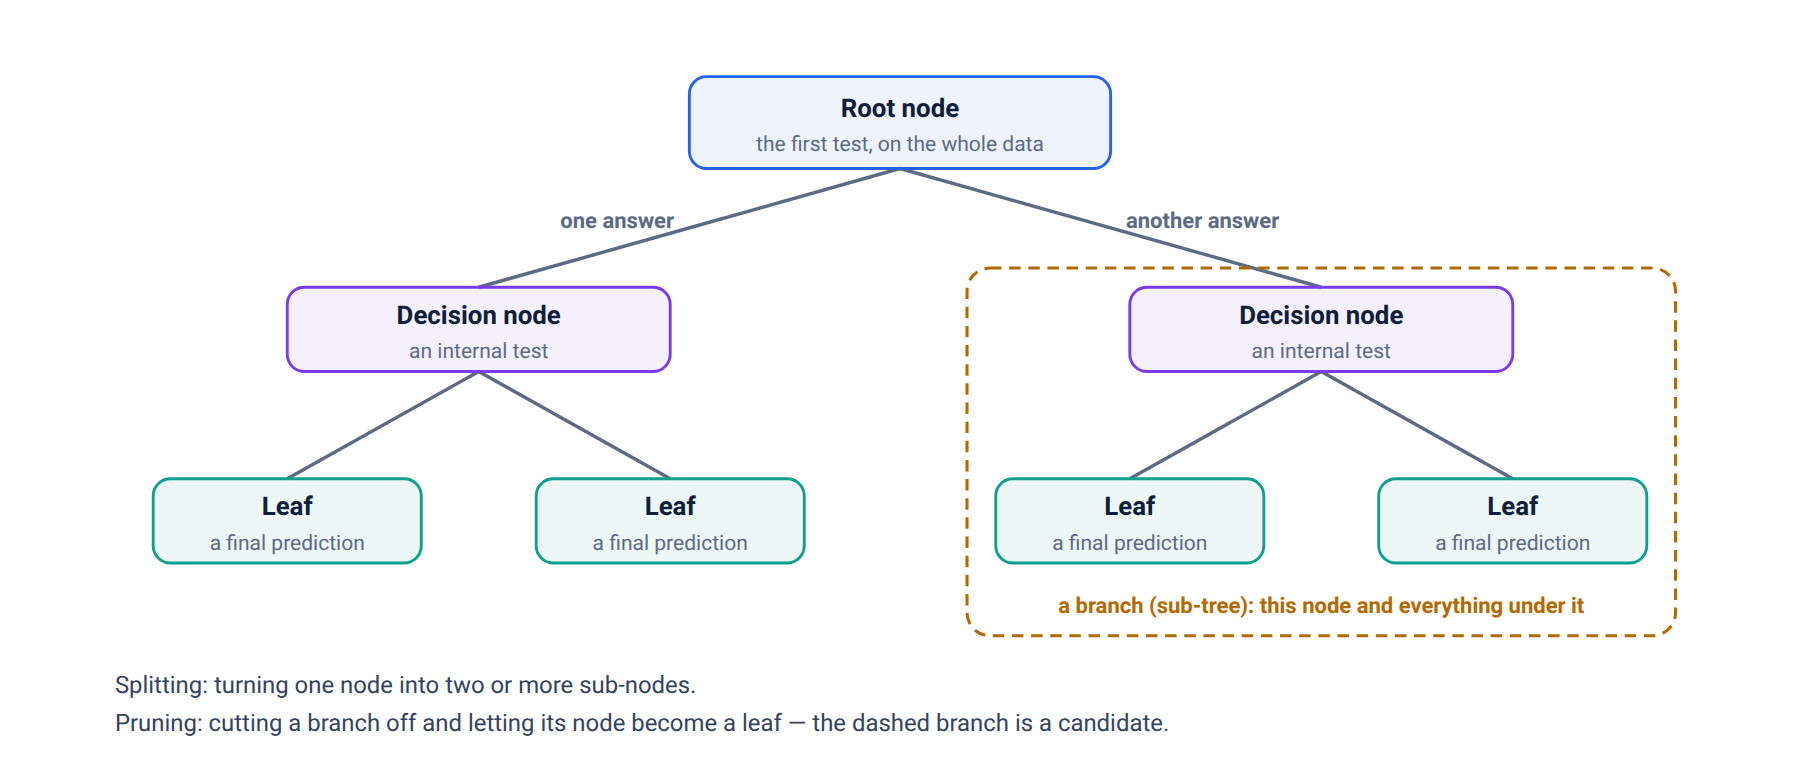

*The anatomy of a decision tree. Classifying a new record means starting at the root and following one branch per test until a leaf is reached.*

> **Two directions through the same tree.** **Deduction** — classifying a new case — walks root to leaf, applying one test per node. **Induction** — building the tree — is the reverse: learning those tests from labeled training data. Sections 10.1.3 to 10.1.5 are induction; Section 10.1.6 is deduction.



## 10.1.3 · The fourteen golf days

*the training data*

The running example is fourteen days of weather and one fact about each: whether golf was played. Four features — outlook, temperature, humidity and wind — and one target, play. Nine days are Yes and five are No. Every row already carries its answer; that is what lets a tree be grown from it, and what the tree will later be checked against.

| Day | Outlook | Temp | Humidity | Windy | Play |
|---|---|---|---|---|---|
| 1 | Rainy | Hot | High | No | **No** |
| 2 | Rainy | Hot | High | Yes | **No** |
| 3 | Overcast | Hot | High | No | **Yes** |
| 4 | Sunny | Mild | High | No | **Yes** |
| 5 | Sunny | Cool | Normal | No | **Yes** |
| 6 | Sunny | Cool | Normal | Yes | **No** |
| 7 | Overcast | Cool | Normal | Yes | **Yes** |
| 8 | Rainy | Mild | High | No | **No** |
| 9 | Rainy | Cool | Normal | No | **Yes** |
| 10 | Sunny | Mild | Normal | No | **Yes** |
| 11 | Rainy | Mild | Normal | Yes | **Yes** |
| 12 | Overcast | Mild | High | Yes | **Yes** |
| 13 | Overcast | Hot | Normal | No | **Yes** |
| 14 | Sunny | Mild | High | Yes | **No** |



#### The steps

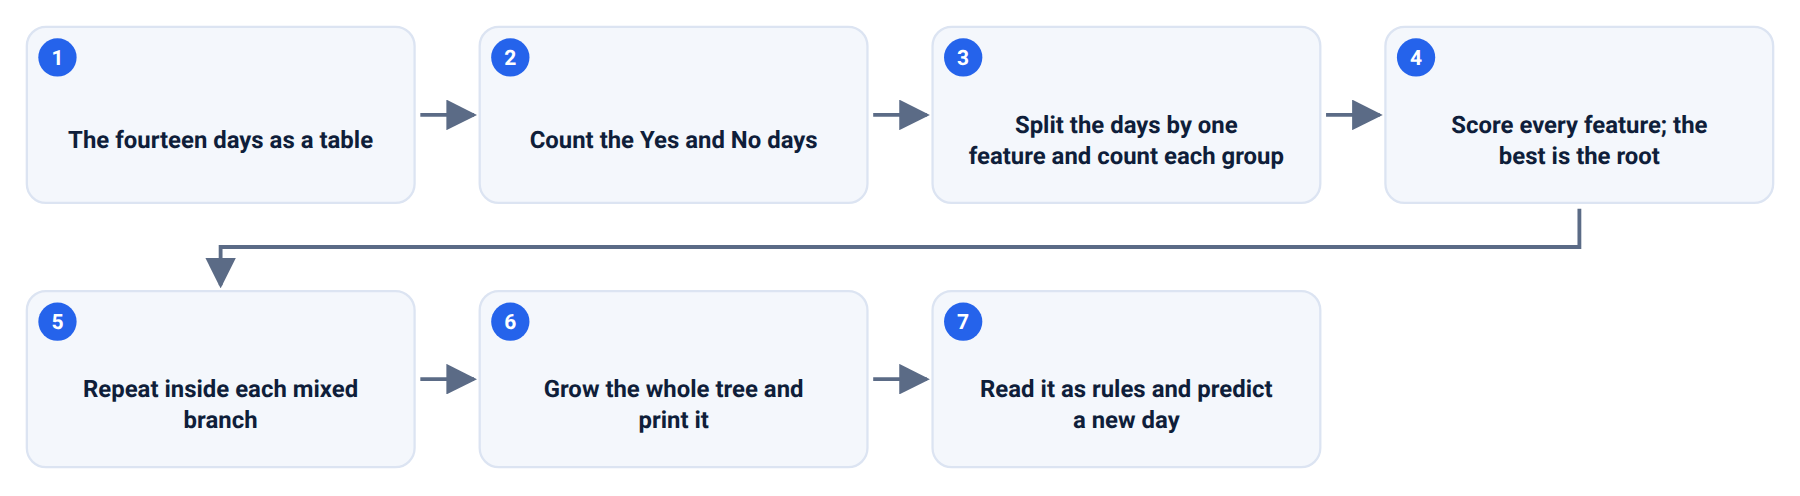

*The code walk of Sections 10.1.3 to 10.1.6. Every number it prints can be checked against the table above.*



#### The golf table

The fourteen days go into a pandas table, one row per day, with the four features and the target as columns. The day numbers of the table above are the row index plus one.



In [2]:
golf = pd.DataFrame({
    "outlook":  ["Rainy", "Rainy", "Overcast", "Sunny", "Sunny", "Sunny", "Overcast",
                 "Rainy", "Rainy", "Sunny", "Rainy", "Overcast", "Overcast", "Sunny"],
    "temp":     ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                 "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "windy":    ["No", "Yes", "No", "No", "No", "Yes", "Yes",
                 "No", "No", "No", "Yes", "Yes", "No", "Yes"],
    "play":     ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
                 "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"],
})
golf.index = range(1, 15)          # number the rows 1 to 14, like the days
FEATURES = ["outlook", "temp", "humidity", "windy"]
golf

,outlook,temp,humidity,windy,play
1,Rainy,Hot,High,No,No
2,Rainy,Hot,High,Yes,No
3,Overcast,Hot,High,No,Yes
4,Sunny,Mild,High,No,Yes
5,Sunny,Cool,Normal,No,Yes
6,Sunny,Cool,Normal,Yes,No
7,Overcast,Cool,Normal,Yes,Yes
8,Rainy,Mild,High,No,No
9,Rainy,Cool,Normal,No,Yes
10,Sunny,Mild,Normal,No,Yes


#### Nine Yes, five No

Before any question is asked, the whole table is one group. `value_counts()` counts how many days fall in each class of the target. The group is mixed, so a question is needed to sort it.



> **Interpretation.** Nine Yes and five No. If the tree had to answer without asking anything, it would say Yes for every day and be right nine times in fourteen. Every question it asks is an attempt to do better than that.



In [3]:
golf["play"].value_counts()

play
Yes    9
No     5
Name: count, dtype: int64

## 10.1.4 · Choosing the first question

*settled by majority, and pure groups*

A tree is a sequence of questions, so growing one means choosing which question to ask first. The algorithm tries every feature as the first question and keeps the one that sorts the days best. “Best” is judged in plain counts.

> **How a question is judged.** Split the fourteen days by a feature and look at each group. Let each group answer with its **majority** — the class most of its days have. The days that answer gets right are the days the group **settles**; the total over all groups is the feature's settled count. A group that is all Yes or all No is **pure**: its majority is right for every day in it, and it needs no further question. A mixed group will need another split.

The feature that settles the most days wins. If two features tie, the one that produces more pure groups wins, because a pure group is a branch that is finished.



#### Worked example — the four features

> **Worked example.** **Outlook.** Sunny 3 Yes / 2 No, Overcast 4 Yes / 0 No, Rainy 2 Yes / 3 No. The majorities settle $3 + 4 + 3 = 10$ days, and Overcast is pure.
> **Temperature.** Hot 2 / 2, Mild 4 / 2, Cool 3 / 1: $2 + 4 + 3 = 9$ settled, no pure group.
> **Humidity.** High 3 / 4, Normal 6 / 1: $4 + 6 = 10$ settled, no pure group.
> **Windy.** No 6 / 2, Yes 3 / 3: $6 + 3 = 9$ settled, no pure group.
>
> Outlook and humidity both settle 10 of 14. Outlook also produces a pure group — every overcast day was played — so **outlook is the root**.

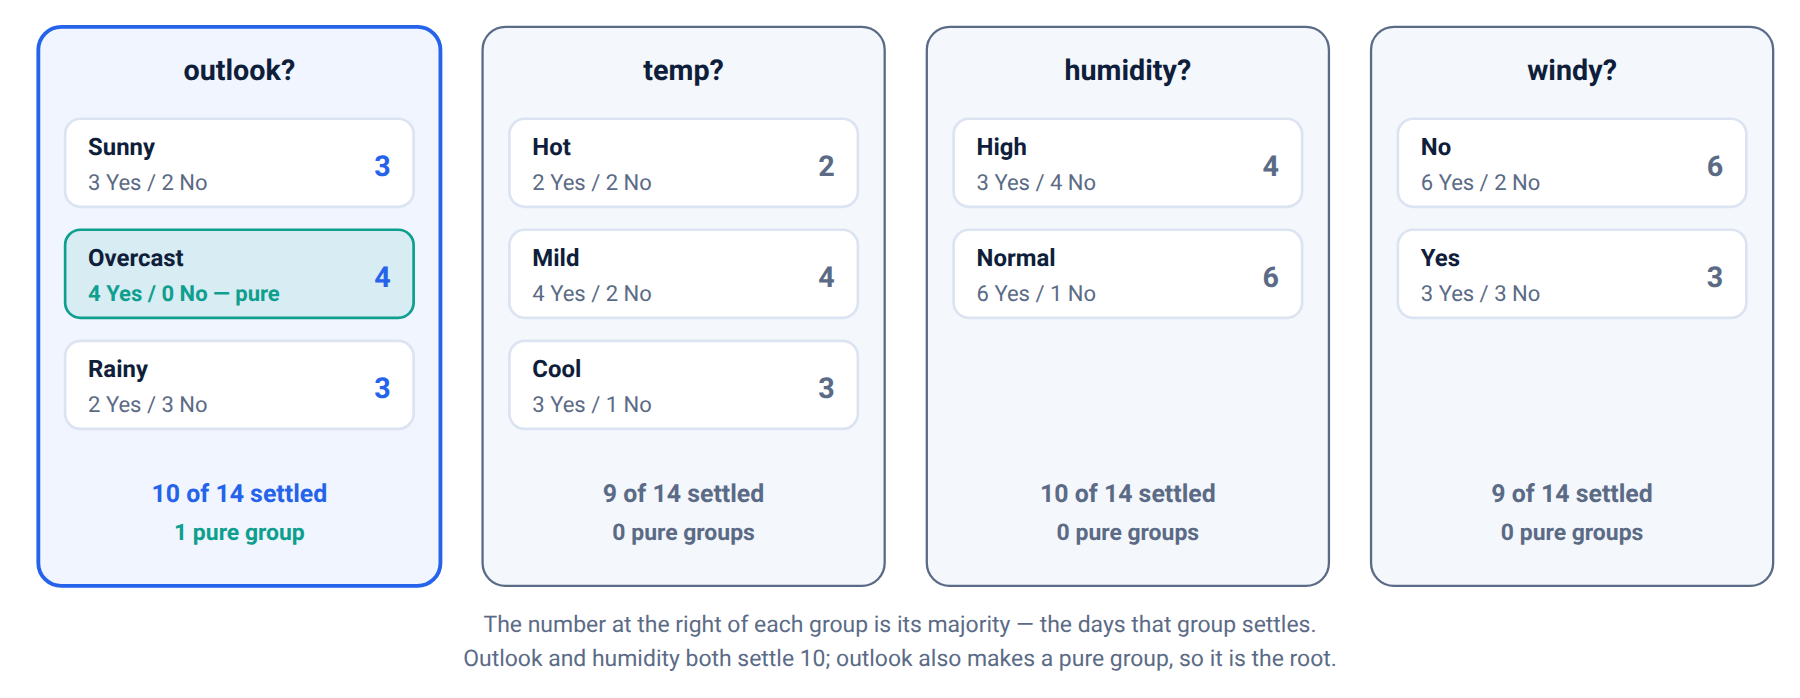

*The four features tried as the first question. A group that is all Yes or all No is pure and needs no further question.*



#### The groups under one feature

`pd.crosstab(rows, columns)` counts how many days fall in each combination of two columns. With the feature as the rows and the target as the columns, the table is exactly the Yes/No count of each group — the numbers of the worked example, for outlook.



> **Interpretation.** Three groups, one per value of outlook.
>
> - **Overcast — 4 Yes, 0 No** is a pure group: every one of its days was played.
> - **Sunny — 3 Yes, 2 No** and **Rainy — 2 Yes, 3 No** are mixed; each majority settles three days.
> - **Settled days**: 3 + 4 + 3 = 10 of the 14, the number the split score counts.



In [4]:
pd.crosstab(golf["outlook"], golf["play"])

play,No,Yes
outlook,,
Overcast,0,4
Rainy,3,2
Sunny,2,3


#### The split score

The same count, written once as a function so it can be applied to any feature and any set of days. `.max(axis=1)` takes each group's majority count from the crosstab, and a group is pure when its row has only one non-zero entry. The function returns the two numbers as a pair; the cell applies it to outlook.

$$\text{settled} = \sum_{\text{groups}} \max(\#\text{Yes}, \#\text{No}) \qquad\qquad \text{pure} = \#\{\text{groups with only one class}\}$$



> **Interpretation.** (10, 1): outlook settles 10 of the 14 days and makes 1 pure group — the numbers of the worked example.



In [5]:
def split_score(df, feature, target="play"):
    """How well one question sorts the days: (days settled by each group's majority, number of pure groups)."""
    counts = pd.crosstab(df[feature], df[target])
    settled = int(counts.max(axis=1).sum())          # each group's majority, added up
    pure = int((counts.gt(0).sum(axis=1) == 1).sum())  # groups with a single class present
    return settled, pure

split_score(golf, "outlook")

(10, 1)

#### All four features scored

The function is called once per feature and the four pairs are put in a table. Python compares pairs position by position, so sorting by the pair puts the most settled days first and breaks a tie by pure groups — exactly the rule of the worked example.



> **Interpretation.** One (settled, pure) pair per feature.
>
> - **Outlook — 10 settled, 1 pure group** comes first, so it becomes the root node.
> - **Humidity — 10 settled, 0 pure** ties outlook on the count but leaves every group mixed, so the tie-break goes against it.
> - **Windy and temperature — 9 settled, 0 pure** barely improve on the 9 days the majority alone gets right.



In [6]:
scores = pd.DataFrame([split_score(golf, f) for f in FEATURES],
                      index=FEATURES, columns=["settled", "pure"])
scores.sort_values(["settled", "pure"], ascending=False)

,settled,pure
outlook,10,1
humidity,10,0
temp,9,0
windy,9,0


#### The best feature

Choosing the winner is a one-line rule: `max()` over the features, comparing their score pairs. The `key=` argument tells `max` what to compare, and when two features tie on both numbers the one listed first is kept. Wrapping the rule in a function matters for the next section, where it is called again inside each branch.



> **Interpretation.** 'outlook' — the root of the tree.



In [7]:
def best_feature(df, features, target="play"):
    """The feature that settles the most days; a tie goes to the one with more pure groups."""
    return max(features, key=lambda f: split_score(df, f, target))

best_feature(golf, FEATURES)

'outlook'

#### Checking the count by hand

> **Try it.** Take humidity. Write down its two groups from the table in Section 10.1.3 — High and Normal — with their Yes and No counts, and check that the majorities add to 10 and that neither group is pure.
>
> *Answer.* High: days 1, 2, 3, 4, 8, 12, 14 — 3 Yes, 4 No, majority No settles 4. Normal: days 5, 6, 7, 9, 10, 11, 13 — 6 Yes, 1 No, majority Yes settles 6. Together 10 settled, and both groups hold both classes, so 0 pure.



## 10.1.5 · Growing the whole tree

*the same search inside each mixed branch*

Outlook is the root, and the fourteen days go down its three branches. Overcast is pure and needs nothing more. Sunny and Rainy are still mixed, so the same search runs again inside each — on that branch's five days only, with the three features not yet used. The growing stops when every branch ends in a pure group.

1. **Start with all the days in one group** — If they all agree, stop: that answer is the prediction. If they are mixed, a question is needed.
2. **Try every feature as the question** — Keep the one that settles the most days, with the purest groups. It becomes a node; each of its values becomes a branch.
3. **Repeat inside each mixed branch** — Only that branch's days, only the features not yet used.
4. **Stop when every branch is pure** — Each pure group is a leaf. The tree is the model.



#### Worked example — the two mixed branches

> **Worked example.** **The Sunny branch** — days 4, 5, 6, 10, 14: 3 Yes, 2 No. Windy: No has days 4, 5, 10, all Yes; Yes has days 6, 14, both No — 5 settled, 2 pure. Humidity: High 1 Yes / 1 No, Normal 2 Yes / 1 No — 3 settled. Temperature: Mild 2 / 1, Cool 1 / 1 — 3 settled. **Windy wins** and finishes the branch.
>
> **The Rainy branch** — days 1, 2, 8, 9, 11: 2 Yes, 3 No. Humidity: High has days 1, 2, 8, all No; Normal has days 9, 11, both Yes — 5 settled, 2 pure. Temperature: Hot 0 / 2, Mild 1 / 1, Cool 1 / 0 — 4 settled, 2 pure. Windy: No 1 / 2, Yes 1 / 1 — 3 settled. **Humidity wins** and finishes the branch.
>
> Every branch now ends in a pure group, so the growing stops: two questions deep, five leaves.



#### The search inside the two mixed branches

Filtering the table to one branch's days and dropping the feature already used gives the smaller problem the algorithm now faces. The cell scores the three remaining features inside the Sunny branch and inside the Rainy branch, and prints both tables.



> **Interpretation.** Inside Sunny, windy settles all 5 days in 2 pure groups; inside Rainy, humidity does the same. Temperature settles neither branch completely. These are the worked example's numbers.



In [8]:
remaining = [f for f in FEATURES if f != "outlook"]
for branch in ["Sunny", "Rainy"]:
    days = golf[golf["outlook"] == branch]                       # only this branch's days
    table = pd.DataFrame([split_score(days, f) for f in remaining],
                         index=remaining, columns=["settled", "pure"])
    print(f"{branch} branch — {len(days)} days, best next question: {best_feature(days, remaining)}")
    print(table.sort_values(["settled", "pure"], ascending=False), "\n")

Sunny branch — 5 days, best next question: windy
          settled  pure
windy           5     2
temp            3     0
humidity        3     0 

Rainy branch — 5 days, best next question: humidity
          settled  pure
humidity        5     2
temp            4     2
windy           3     0 



#### The function that grows the tree

The four steps of the algorithm become one function that handles one group of days and calls itself for each branch — a **recursive** function. A pure group becomes a leaf; a group with no features left becomes a leaf labeled with its majority; otherwise the best feature is chosen and the function is called again on each of its groups, with that feature removed. The tree is stored as nested dictionaries: a leaf holds a label, a node holds a question and one branch per value.



In [9]:
def grow_tree(df, features, target="play"):
    """Grow a decision tree by the counting rule: the best question, then the same search in each branch."""
    labels = df[target]
    if labels.nunique() == 1:                                # pure: a leaf
        return {"leaf": labels.iloc[0], "n": len(df)}
    if not features:                                         # nothing left to ask: the majority answers
        return {"leaf": labels.value_counts().sort_index().idxmax(), "n": len(df)}
    question = best_feature(df, features, target)
    rest = [f for f in features if f != question]
    return {"question": question, "n": len(df),
            "branches": {value: grow_tree(group, rest, target)         # the same search, per branch
                         for value, group in df.groupby(question)}}

#### The tree

The tree is grown from the whole table, and a second small function prints it with one level of indentation per question, so the nested dictionaries can be read as a tree.



> **Interpretation.** The tree of the worked example, printed one level per indent.
>
> - **Outlook** is the root; **Overcast** is a leaf at once (4 days, all Yes).
> - **Under Rainy** the question is humidity: High leads to No, Normal to Yes.
> - **Under Sunny** the question is windy: No leads to Yes, Yes to No.
> - **Five leaves, every one pure, two questions deep** — the growing stops because nothing is left to split.



In [10]:
def print_tree(node, indent=""):
    if "leaf" in node:
        print(f"{indent}-> play = {node['leaf']}   ({node['n']} days)")
        return
    print(f"{indent}[{node['question']}?]   ({node['n']} days)")
    for value, child in node["branches"].items():
        print(f"{indent}  {value}:")
        print_tree(child, indent + "    ")

tree = grow_tree(golf, FEATURES)
print_tree(tree)

[outlook?]   (14 days)
  Overcast:
    -> play = Yes   (4 days)
  Rainy:
    [humidity?]   (5 days)
      High:
        -> play = No   (3 days)
      Normal:
        -> play = Yes   (2 days)
  Sunny:
    [windy?]   (5 days)
      No:
        -> play = Yes   (3 days)
      Yes:
        -> play = No   (2 days)


#### The finished tree

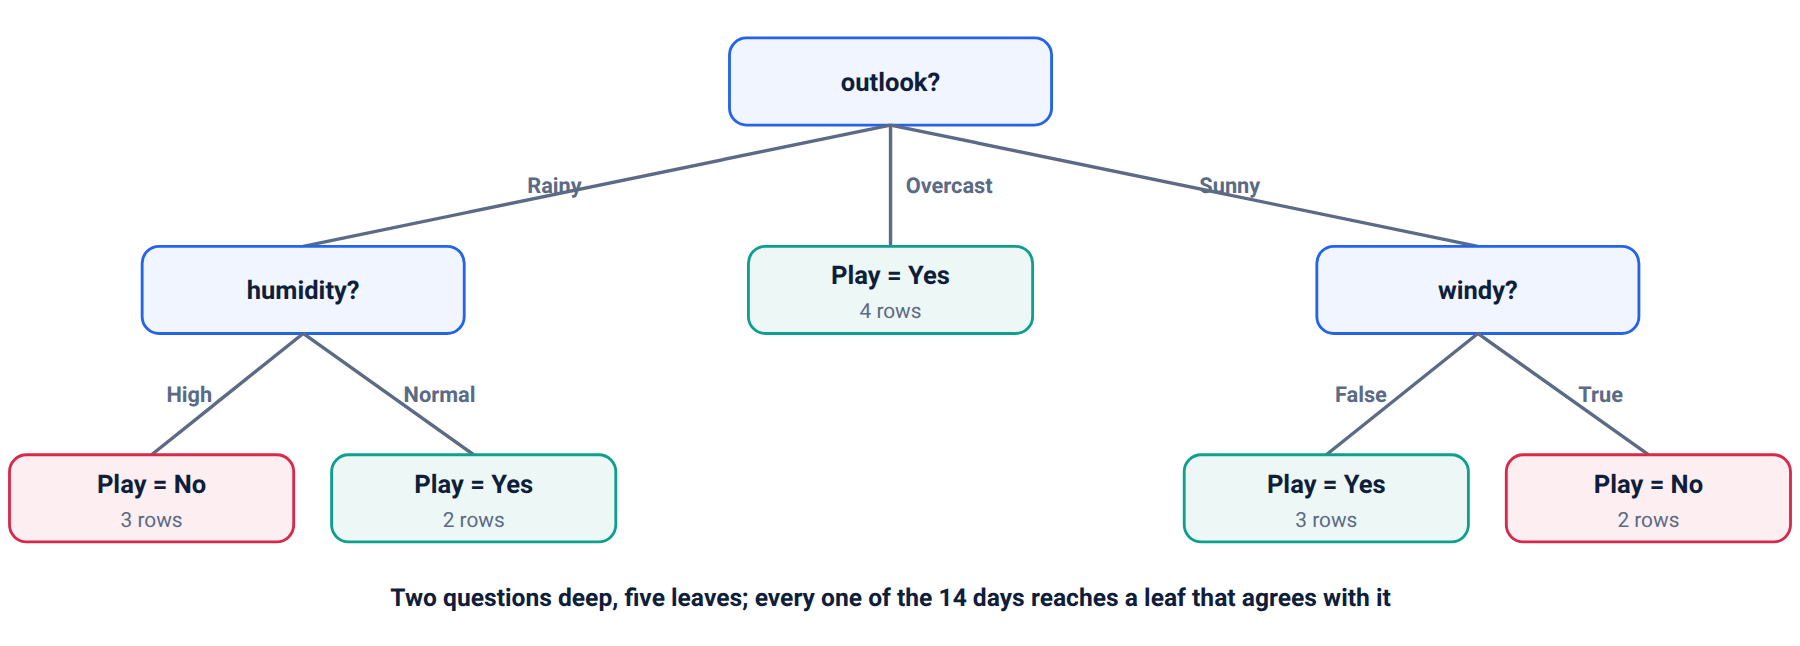

*The tree grown from the fourteen golf days. Every leaf is pure, so the growing stopped.*



## 10.1.6 · Reading the tree

*IF–THEN rules, and a new day*

Every path from the root to a leaf is one **IF–THEN rule**, and the whole tree is five of them. This is the form a business can act on, and it is why the decision tree is the algorithm this chapter works through.

- IF overcast THEN play
- IF sunny AND not windy THEN play
- IF sunny AND windy THEN do not play
- IF rainy AND humidity high THEN do not play
- IF rainy AND humidity normal THEN play

Predicting a new day is deduction: start at the root and answer one question per node. A sunny, windy day goes Sunny → Windy? → Yes → do not play. The prediction can then be compared with what actually happened, which is the comparison Part 10.2 is built on.



#### Every path as a rule

A function walks the tree and collects the conditions along each path; when it reaches a leaf it prints the conditions joined by AND and the leaf's answer. Five paths, five rules.



In [11]:
def tree_rules(node, conditions=()):
    if "leaf" in node:
        print("IF " + " AND ".join(conditions) + f" THEN play = {node['leaf']}")
        return
    for value, child in node["branches"].items():
        tree_rules(child, conditions + (f"{node['question']} = {value}",))

tree_rules(tree)

IF outlook = Overcast THEN play = Yes
IF outlook = Rainy AND humidity = High THEN play = No
IF outlook = Rainy AND humidity = Normal THEN play = Yes
IF outlook = Sunny AND windy = No THEN play = Yes
IF outlook = Sunny AND windy = Yes THEN play = No


#### Predicting a new day

The prediction function follows the branch matching the day's value at each question until it reaches a leaf. A new day is written as a dictionary of feature values; the cell predicts the sunny, windy day of the text, and prints the path it takes.



> **Interpretation.** Do not play. The path used two of the four features; temperature and humidity were never asked about, because the Sunny branch was settled by windy alone.



In [12]:
def predict(node, row):
    """Walk from the root to a leaf, following the branch that matches the row at each question."""
    while "leaf" not in node:
        value = row[node["question"]]
        if value not in node["branches"]:
            return None                       # a value the training days never showed: no answer
        node = node["branches"][value]
    return node["leaf"]

new_day = {"outlook": "Sunny", "temp": "Mild", "humidity": "High", "windy": "Yes"}
print("Sunny -> windy? -> Yes ->", predict(tree, new_day))

Sunny -> windy? -> Yes -> No


#### The tree on its own fourteen days

Running every training day back through the tree — `.apply(..., axis=1)` calls the function once per row — and comparing with the true answers gives the training accuracy.



> **Interpretation.** 100%. Every leaf agrees with its days, because the algorithm kept asking questions until every group was pure. That is how well the tree fits the days it was grown from; it is not yet evidence of how well it predicts a day it has not seen. Part 10.2 measures that.



In [13]:
golf_checked = golf.assign(predicted=golf.apply(lambda row: predict(tree, row), axis=1))
correct = golf_checked["predicted"] == golf_checked["play"]
print(f"right on {correct.sum()} of {len(correct)} training days: {correct.mean():.0%}")
golf_checked

right on 14 of 14 training days: 100%


,outlook,temp,humidity,windy,play,predicted
1,Rainy,Hot,High,No,No,No
2,Rainy,Hot,High,Yes,No,No
3,Overcast,Hot,High,No,Yes,Yes
4,Sunny,Mild,High,No,Yes,Yes
5,Sunny,Cool,Normal,No,Yes,Yes
6,Sunny,Cool,Normal,Yes,No,No
7,Overcast,Cool,Normal,Yes,Yes,Yes
8,Rainy,Mild,High,No,No,No
9,Rainy,Cool,Normal,No,Yes,Yes
10,Sunny,Mild,Normal,No,Yes,Yes


#### Where Part 10.1 leaves us

> **Key idea.** A tree was grown from fourteen labeled days by counting, drawn, and read as five rules; it predicts a new day by walking root to leaf, and it scores 100% on its own training days. Part 10.2 asks the tree about days it has not seen and reads the four boxes that result. The rest of this part applies the same method to a real dataset with a library, so the homework can ask questions of it.



## 10.1.7 · The same tree, with scikit-learn

*three lines, and where the two trees differ*

Sections 10.1.4 to 10.1.6 grew the tree one question at a time, so that every count could be checked by hand. A library does the same job in three lines: one to turn the words into numbers, one to grow the tree, one to print it. The fourteen days are small enough that both trees can be compared, which is the point of doing it here rather than straight on a real dataset.

> **Two differences to expect.** `DecisionTreeClassifier` reads numbers only, and it splits a group in two. The counting rule of Section 10.1.4 split outlook into its three values at once. Both trees are grown from the same fourteen days, so the two differences to watch for are the shape of the tree and the days it is asked about afterwards.



#### Text into numbers

Each column of words becomes a column of whole numbers: `.astype('category').cat.codes` numbers the values of a column in alphabetical order. Outlook becomes Overcast 0, Rainy 1, Sunny 2; humidity High 0, Normal 1; windy No 0, Yes 1. The column names do not change, so the printed tree still reads in the vocabulary of the fourteen days.



> **Interpretation.** The same table, in numbers. Day 1 is Rainy, Hot, High, not windy, so it reads 1, 1, 0, 0 — the numbers are labels, not quantities, and nothing about the days has changed.



In [14]:
codes = golf[FEATURES].apply(lambda col: col.astype("category").cat.codes)
codes.head()

,outlook,temp,humidity,windy
1,1,1,0,0
2,1,1,0,1
3,0,1,0,0
4,2,2,0,0
5,2,0,1,0


#### The tree in one line

`DecisionTreeClassifier()` makes an empty tree and `.fit(features, target)` grows it. The `random_state` setting only fixes how ties are broken, so that everyone in the room gets the same tree. This one line does the work of Section 10.1.5.



> **Interpretation.** A tree four questions deep with seven leaves, against the two questions and five leaves of the tree grown by counting. The next cell shows what it asks.



In [15]:
from sklearn.tree import DecisionTreeClassifier, export_text

model = DecisionTreeClassifier(random_state=0).fit(codes, golf["play"])
print("depth", model.get_depth(), "· leaves", model.get_n_leaves())

depth 4 · leaves 7


#### The library's tree, printed

`export_text` prints the tree as indented rules. A line such as `outlook <= 0.50` means “is the outlook code 0 or less” — that is, is it Overcast — and the indented lines below it are what follows when the answer is yes.



> **Interpretation.** The first question is outlook, and the overcast days go straight to a leaf that says play — the same first question and the same pure group that the counting found in Section 10.1.4. Below it the trees part: because this one can only split a group in two, the five sunny and five rainy days stay together in a group of ten, and humidity is the best single question for those ten — it settles 8 of them, against 7 for windy and 6 for splitting the outlook again. The counting tree never met that group, because it had already separated sunny from rainy.



In [16]:
print(export_text(model, feature_names=list(codes.columns), class_names=list(model.classes_)))

|--- outlook <= 0.50
|   |--- class: Yes
|--- outlook >  0.50
|   |--- humidity <= 0.50
|   |   |--- outlook <= 1.50
|   |   |   |--- class: No
|   |   |--- outlook >  1.50
|   |   |   |--- windy <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- windy >  0.50
|   |   |   |   |--- class: No
|   |--- humidity >  0.50
|   |   |--- windy <= 0.50
|   |   |   |--- class: Yes
|   |   |--- windy >  0.50
|   |   |   |--- temp <= 1.00
|   |   |   |   |--- class: No
|   |   |   |--- temp >  1.00
|   |   |   |   |--- class: Yes



#### The same fourteen days

`.score(features, target)` predicts every row and reports the share it gets right — the training accuracy of Section 10.1.6, computed by the library.



> **Interpretation.** 1.0 — right on all fourteen, exactly like the tree grown by counting. Two trees of different shapes fit the same fourteen days perfectly, which is the first sign that the days do not pin down one tree.



In [17]:
model.score(codes, golf["play"])

1.0

#### The same new day

The sunny, mild, high-humidity, windy day of Section 10.1.6 has to be written in the same numbers as the training table, or the codes would mean different things. Joining it to the fourteen days before coding and then taking the last row does that.



> **Interpretation.** No — the same answer the counting tree gave. The two trees ask different questions and arrive at the same decision for this day.



In [18]:
day_codes = (pd.concat([golf[FEATURES], pd.DataFrame([new_day])])
               .apply(lambda col: col.astype("category").cat.codes).tail(1))
model.predict(day_codes)[0]

'No'

#### Where the two trees differ

Three outlooks, three temperatures, two humidities and two wind values make 36 possible days, of which the data contains fourteen. Asking both trees about all 36 and keeping the rows where they disagree shows exactly how much the fourteen days left undecided.



> **Interpretation.** Three days out of 36, and not one of them is among the fourteen. Both trees are right on every day they were given and still answer differently about days nobody has seen. Fourteen days are not enough to decide between them — which is why a model is judged on days it was not grown from, the subject of Part 10.2.



In [19]:
from itertools import product

values = {f: sorted(golf[f].unique()) for f in FEATURES}
all_days = pd.DataFrame([dict(zip(values, combo)) for combo in product(*values.values())])
all_codes = (pd.concat([golf[FEATURES], all_days])
               .apply(lambda col: col.astype("category").cat.codes).tail(len(all_days)))
all_days["counting_tree"] = all_days.apply(lambda row: predict(tree, row), axis=1)
all_days["library_tree"] = model.predict(all_codes)
all_days[all_days["counting_tree"] != all_days["library_tree"]]

,outlook,temp,humidity,windy,counting_tree,library_tree
15,Rainy,Cool,Normal,Yes,Yes,No
19,Rainy,Hot,Normal,Yes,Yes,No
35,Sunny,Mild,Normal,Yes,No,Yes


#### Which tree to use

> **Key idea.** The counting version is the one to think with: it is short enough to check by hand, and its five rules are the ones a person can read. The library version is the one to work with, because it grows a tree from thousands of rows in the same one line. The rest of this part uses the library, and the homework is written against it.



## 10.1.8 · A real dataset — the iris flowers

*the same method with scikit-learn*

Fourteen rows can be worked by hand. Real datasets cannot, so the method is now applied with a library. The dataset is one of the oldest in statistics: 150 iris flowers measured by the botanist Edgar Anderson and published by Ronald Fisher in 1936 — 50 flowers of each of three species, and four measurements of each flower, in centimeters: the length and width of the sepal (the outer leaf of the flower) and of the petal. It is bundled with scikit-learn, so it loads without a download.

> **The question.** Can a flower's species be told from its four measurements — and what rules does the tree find? The target is the species: three classes, so this is a multi-class problem. The features are the four measurements.

> **The library.** scikit-learn's `DecisionTreeClassifier` grows a tree the way Section 10.1.5 did, with one difference: its features are numbers, so a question is a cut-point — “petal width ≤ 0.8?” — that sends each flower left or right, and the algorithm tries cut-points the way the golf tree tried features, scoring how mixed the two groups are with a formula rather than a count. The idea is the same: keep the question that leaves its groups least mixed, then search again inside each mixed group.



#### The steps

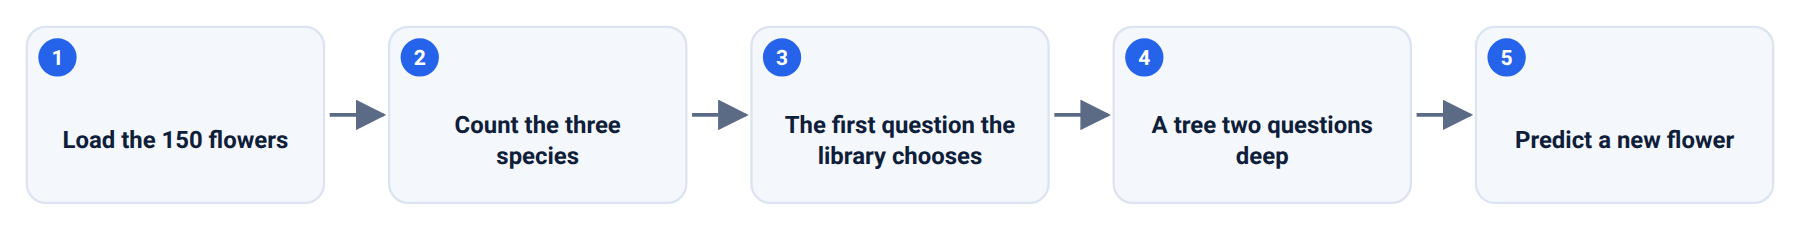

*The iris walk. The homework in Section 10.1.10 continues from here.*



#### Loading the flowers

`load_iris(as_frame=True)` returns the data as a pandas table plus the species of each flower as a number 0, 1, 2, with the names in a separate list. The cell renames the columns to short names, adds a species column with the names, and shows the first rows.



> **Interpretation.** 150 rows and 5 columns: four measurements in centimeters and the species. The first flowers are all setosa, because the file is sorted by species.



In [20]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
flowers = iris.data.copy()
flowers.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
flowers["species"] = iris.target_names[iris.target]     # 0/1/2 -> setosa / versicolor / virginica
print("shape:", flowers.shape)
flowers.head()

shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### Three species, fifty each

As with the golf days, the whole table is first one group; the count of each class says how mixed it is.



> **Interpretation.** 50 setosa, 50 versicolor, 50 virginica. A tree that asked nothing would be right one time in three.



In [21]:
flowers["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

#### The first question the library chooses

`DecisionTreeClassifier(max_depth=1)` grows a tree of one question. `.fit(X, y)` is the training step: the features `X` and the target `y` go in, and the tree comes back. `export_text` prints it as indented rules, the way Section 10.1.5 printed the golf tree.



> **Interpretation.** One question — petal width ≤ 0.8 cm — sends every setosa left and every other flower right. The left group is pure, like the Overcast branch of the golf tree; the right group still mixes versicolor and virginica, so it needs another question.



In [22]:
from sklearn.tree import DecisionTreeClassifier, export_text

X = flowers[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = flowers["species"]

stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X, y)
print(export_text(stump, feature_names=list(X.columns), class_names=list(stump.classes_)))

|--- petal_width <= 0.80
|   |--- class: setosa
|--- petal_width >  0.80
|   |--- class: versicolor



#### A tree two questions deep

Raising `max_depth` to 2 lets the algorithm ask one more question inside the mixed group. The cell prints the tree and its training accuracy — `.score(X, y)` is the share of the 150 flowers the tree gets right.



> **Interpretation.** The second question is petal width again, at 1.75 cm: at most 1.75 is called versicolor, above it virginica. Three leaves and 96% on the training flowers — the two right-hand leaves are not pure, so six flowers land in a leaf whose answer is not their species.



In [23]:
tree2 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X, y)
print(export_text(tree2, feature_names=list(X.columns), class_names=list(tree2.classes_)))
print(f"training accuracy: {tree2.score(X, y):.1%}")

|--- petal_width <= 0.80
|   |--- class: setosa
|--- petal_width >  0.80
|   |--- petal_width <= 1.75
|   |   |--- class: versicolor
|   |--- petal_width >  1.75
|   |   |--- class: virginica

training accuracy: 96.0%


#### Predicting a new flower

`.predict()` walks a new flower through the tree. The flower is written as a one-row table with the same four columns, in the same order, as the training data.



> **Interpretation.** Versicolor. Its petal width of 1.5 cm fails the first test (it is more than 0.8) and passes the second (at most 1.75), so it lands in the versicolor leaf — the same walk as the sunny, windy day, with cut-points in place of categories.



In [24]:
new_flower = pd.DataFrame([[5.8, 3.0, 4.5, 1.5]], columns=X.columns)
print("petal width 1.5 -> not <= 0.8, and <= 1.75 ->", tree2.predict(new_flower)[0])

petal width 1.5 -> not <= 0.8, and <= 1.75 -> versicolor


#### From here

> **Key idea.** The golf tree and the iris tree are the same object: a sequence of questions chosen from labeled data, ending in leaves that answer. What changes with a real dataset is only the tool. The homework below continues with the flowers: a deeper tree, its rules, new flowers to classify, and a question about which measurements ask the better questions.



## 10.1.9 · Glossary

*the terms of this part*

| Term | Meaning |
|---|---|
| **Supervised learning** | Learning from data that already carries the answers (the target). |
| **Feature / target** | A column used to predict / the column to be predicted. |
| **Training set / test set** | The rows a model learns from / the rows it is judged on, hidden while it learns. |
| **Classification / regression** | Predicting a category / predicting a number. |
| **Binary / multi-class** | Two classes / three or more. |
| **Positive class** | In a binary problem, the class being looked for. |
| **Decision tree** | A model that asks one question per node; every path from the root ends in a prediction. |
| **Root, decision node, leaf** | The first question, an inner question, a final answer. |
| **Pure group** | A group whose members all have the same class; it needs no further question. |
| **Settled by majority** | The days a group's most common class gets right; the feature's total is its score. |
| **IF–THEN rule** | One path from the root to a leaf, written as conditions and an answer. |
| **Training accuracy** | The share of the training rows a model gets right — how well it fits, not how well it predicts. |



## 10.1.10 · Homework

*the graded work, on the iris flowers*

The exercises continue Section 10.1.8 on the iris flowers, in the order this part taught the ideas: look at the data, grow a tree, read it as rules, predict new cases, compare questions, and name the kind of problem. Each exercise has a code cell for your work and a text cell for your answer.

**Student information** — double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework dataset — the iris flowers, and three new flowers

*run this cell, but do not modify it*

Run this cell once and do not edit it. It reloads the 150 flowers as `flowers`, the features as `X` and the target as `y`, exactly as in Section 10.1.8, and creates `new_flowers`: three flowers whose species the exercises ask you to predict.



In [25]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text

iris = load_iris(as_frame=True)
flowers = iris.data.copy()
flowers.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
flowers["species"] = iris.target_names[iris.target]
X = flowers[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = flowers["species"]

new_flowers = pd.DataFrame([[5.0, 3.4, 1.5, 0.2],
                            [6.7, 3.1, 4.7, 1.5],
                            [6.3, 2.8, 5.1, 1.9]], columns=X.columns, index=["A", "B", "C"])
print("flowers:", flowers.shape)
new_flowers

flowers: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width
A,5.0,3.4,1.5,0.2
B,6.7,3.1,4.7,1.5
C,6.3,2.8,5.1,1.9


#### Exercise 1 — Look at the data

For each species, find the smallest and largest `petal_length` and `petal_width` (`flowers.groupby("species")[[...]].agg(["min", "max"])`). Which species is separated from the other two by petal size alone, with no overlap? Say how that shows up in the first question the library chose in Section 10.1.8.



In [26]:
# YOUR CODE HERE (Exercise 1)

#### Your answer — Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — A deeper tree

Grow a tree with `max_depth=3` on all four features (use `random_state=0`) and print it with `export_text`. How many leaves does it have, and what is its training accuracy (`.score(X, y)`)? Compare both numbers with the depth-2 tree of Section 10.1.8.



In [27]:
# YOUR CODE HERE (Exercise 2)

#### Your answer — Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — The tree as rules

Write the depth-2 tree of Section 10.1.8 as IF–THEN rules in words, one per leaf, the way Section 10.1.6 wrote the golf tree. Then say which single measurement the whole tree depends on.



In [28]:
# YOUR CODE HERE (Exercise 3)

#### Your answer — Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — Three new flowers

Walk each of the three flowers in `new_flowers` through the depth-2 rules by hand and write down your prediction. Then check with `.predict(new_flowers)`. Do the two agree? For flower C, say which test it passed and failed.



In [29]:
# YOUR CODE HERE (Exercise 4)

#### Your answer — Exercise 4

*Double-click this cell and type your answer here.*



#### Exercise 5 — The measurements that ask the better questions

Grow a depth-2 tree on the two sepal measurements only (`flowers[["sepal_length", "sepal_width"]]`) and another on the two petal measurements only. Print both and compare their training accuracies. Which pair sorts the flowers into purer groups, and why does that make its questions better?



In [30]:
# YOUR CODE HERE (Exercise 5)

#### Your answer — Exercise 5

*Double-click this cell and type your answer here.*



#### Exercise 6 — Binary and multi-class

Is the iris problem binary or multi-class, and why? A garden center only wants to know whether a flower is a setosa. Make that target (`is_setosa = (flowers["species"] == "setosa")`), grow a `max_depth=1` tree on all four features to predict it, print the one rule, and name the positive class.



In [31]:
# YOUR CODE HERE (Exercise 6)

#### Your answer — Exercise 6

*Double-click this cell and type your answer here.*



#### Bonus — a second real dataset

scikit-learn also bundles 178 wines from three growers with 13 chemical measurements each: `from sklearn.datasets import load_wine`, then `load_wine(as_frame=True)`. Grow a depth-2 tree on all 13 measurements, print it, and report its training accuracy. Which measurement is the root question, and how many of the 178 wines does the first question settle into a pure group?



In [32]:
# YOUR CODE HERE (Bonus)

#### Your answer — the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime → Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

